In [6]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
tif_path = "/home/aman-/aman/irrigation/backend/data/raw/insat_pet/3RIMG_01APR2022_0015_L3C_PET_DLY_V01R00.tif"

with rasterio.open(tif_path) as src:
    data = src.read(1)  # First band

    print("Shape:", data.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("NoData Value:", src.nodata)

Shape: (15, 29)
CRS: EPSG:4326
Bounds: BoundingBox(left=78.68167043181468, bottom=28.655648508861507, right=80.11829136300689, top=29.398728300857478)
Resolution: (0.04953865279973142, 0.04953865279973142)
NoData Value: -9999.0


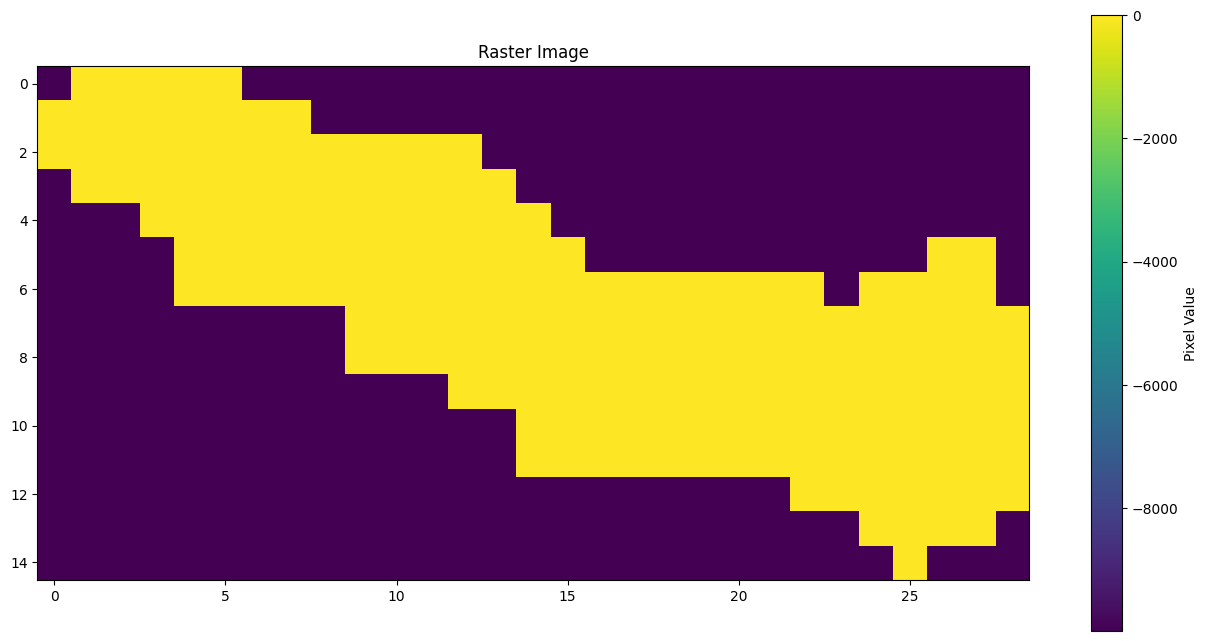

In [10]:
plt.figure(figsize=(16, 8))
plt.imshow(data, cmap="viridis")
plt.colorbar(label="Pixel Value")
plt.title("Raster Image")
plt.show()

In [12]:
# valid_pixels = data[data != src.nodata]
valid_pixels = data

print("Minimum:", np.min(valid_pixels))
print("Maximum:", np.max(valid_pixels))
print("Mean:", np.mean(valid_pixels))
print("Median:", np.median(valid_pixels))
print("Std Dev:", np.std(valid_pixels))
print("Count of Valid Pixels:", valid_pixels.size)
print("Count of NoData Pixels:", np.sum(data == src.nodata))
print("Unique Values:", np.unique(valid_pixels))
print("Unique Values Count:", len(np.unique(valid_pixels)))
print("length of valid pixels:", len(valid_pixels))

Minimum: -9999.0
Maximum: 2.2520065307617188
Mean: -5699.807468729731
Median: -9999.0
Std Dev: 4950.98866378262
Count of Valid Pixels: 435
Count of NoData Pixels: 248
Unique Values: [-9.99900000e+03  1.40699780e+00  1.42100549e+00  1.43281782e+00
  1.46517467e+00  1.47018731e+00  1.48482776e+00  1.48533940e+00
  1.49702895e+00  1.50835395e+00  1.51013994e+00  1.52174830e+00
  1.53276026e+00  1.53991985e+00  1.54688334e+00  1.55834162e+00
  1.56968045e+00  1.57359433e+00  1.57644939e+00  1.57997215e+00
  1.58316410e+00  1.58506787e+00  1.58904362e+00  1.59190130e+00
  1.59383965e+00  1.59642136e+00  1.59962296e+00  1.60477638e+00
  1.60596120e+00  1.60683966e+00  1.60729444e+00  1.61130583e+00
  1.61544013e+00  1.61640179e+00  1.61675930e+00  1.61874962e+00
  1.61886919e+00  1.61929905e+00  1.62219286e+00  1.62417281e+00
  1.62576091e+00  1.62841773e+00  1.62932861e+00  1.63063085e+00
  1.63100851e+00  1.63265860e+00  1.63297689e+00  1.63297880e+00
  1.63411987e+00  1.63449979e+00  1.63

In [ ]:
pixels = data.flatten()

df = pd.DataFrame({
    "pixel_value": pixels
})

df.head(500)

,pixel_value
0,-9999.000000
1,2.102210
2,2.005014
3,2.110288
4,2.017789
5,2.009291
6,-9999.000000
7,-9999.000000
8,-9999.000000
9,-9999.000000


In [9]:
output_csv = "pixel_values.csv"

clean_df.to_csv(output_csv, index=False)

print(f"Saved to {output_csv}")

Saved to pixel_values.csv


In [7]:
if src.nodata is not None:
    pixels = pixels[pixels != src.nodata]

clean_df = pd.DataFrame({
    "pixel_value": pixels
})

print("Valid Pixels:", len(clean_df))
clean_df.head()

Valid Pixels: 187


,pixel_value
0,2.102210
1,2.005014
2,2.110288
3,2.017789
4,2.009291


In [10]:
rows, cols = np.where(data != src.nodata)

coords = []

with rasterio.open(tif_path) as src:
    for row, col in zip(rows, cols):
        x, y = src.xy(row, col)

        coords.append([
            x,
            y,
            data[row, col]
        ])

coord_df = pd.DataFrame(
    coords,
    columns=["longitude", "latitude", "value"]
)

coord_df.head()

,longitude,latitude,value
0,78.755978,29.373959,2.102210
1,78.805517,29.373959,2.005014
2,78.855056,29.373959,2.110288
3,78.904594,29.373959,2.017789
4,78.954133,29.373959,2.009291


In [11]:
coord_df.to_csv("raster_pixels_with_coordinates.csv", index=False)

print("Saved raster pixel data with coordinates")

Saved raster pixel data with coordinates


In [12]:
from pathlib import Path

folder = Path("tiff_folder")

results = []

for tif_file in folder.glob("*.tif"):

    with rasterio.open(tif_file) as src:
        data = src.read(1)

        if src.nodata is not None:
            valid = data[data != src.nodata]
        else:
            valid = data.flatten()

        mean_val = np.mean(valid)

        results.append({
            "file": tif_file.name,
            "mean": mean_val
        })

df = pd.DataFrame(results)

df

""


In [15]:
from pathlib import Path
import re
import pandas as pd

filename = Path(tif_path).name

date_str = re.search(r'(\d{2}[A-Z]{3}\d{4})', filename).group(1)

date = pd.to_datetime(date_str, format="%d%b%Y")

print(date)

2022-04-01 00:00:00


In [17]:
df = df.set_index("date")

monthly_df = df.resample("M")["mean"].mean()

print(monthly_df)

date
2021-11-30    1.179484
2021-12-31    0.832246
2022-01-31    0.600769
2022-02-28    0.554904
2022-03-31    1.852234
2022-04-30    2.137275
2022-05-31         NaN
2022-06-30         NaN
2022-07-31         NaN
2022-08-31         NaN
2022-09-30         NaN
2022-10-31         NaN
2022-11-30    1.071049
2022-12-31    1.097137
2023-01-31    0.910023
2023-02-28    1.129503
2023-03-31    1.331230
2023-04-30    1.876348
2023-05-31         NaN
2023-06-30         NaN
2023-07-31         NaN
2023-08-31         NaN
2023-09-30         NaN
2023-10-31         NaN
2023-11-30    1.024167
2023-12-31    0.944703
2024-01-31    0.868614
2024-02-29    0.780405
2024-03-31    1.519581
2024-04-30    1.871017
2024-05-31         NaN
2024-06-30         NaN
2024-07-31         NaN
2024-08-31         NaN
2024-09-30         NaN
2024-10-31         NaN
2024-11-30    1.628770
2024-12-31    1.139916
2025-01-31         NaN
2025-02-28    0.925172
2025-03-31    1.451863
2025-04-30    2.123214
2025-05-31         NaN
2025-0